# $\lambda_{topo}$ 是怎么计算的

这个 notebook 用二维 Dirac toy model 演示 `graphene/tb/core.py` 里 `lambda_topo` 的两部分来源：

1. `estimate_dirac_winding_numbers()` 先算 Dirac 点的绕数
2. `integrate_fermi_surface_observables()` 再算分母费米线积分

$$
\oint_{FS} ds\,\frac{|\nabla_k E|}{\Delta E^2}
$$

最后在 `lambda_decomposition_scan()` 里组装成

$$
\lambda_{topo}
=
C_{topo}
\frac{(|W_K|+|W_{K'}|)^2}
{\oint_{FS} ds\,|\nabla_k E|/\Delta E^2}
$$

这个 notebook 会按 `learning-demo` 的顺序来讲：先说明问题对象，再说明绕数和分母积分的解析公式，再写 toy model 代码，最后用图把几何对象、相位绕圈、积分核和参数扫描展示出来。


## 0. 问题对象

这段代码最终要算的是 `lambda_topo` 在乘上公共 prefactor 之前的主体：

$$
\widetilde{\lambda}_{topo}
=
\frac{(|W_K|+|W_{K'}|)^2}
{\oint_{FS} ds\,|\nabla_k E|/\Delta E^2}
$$

这里面有两类核心对象：

- 拓扑输入：$W_K$ 和 $W_{K'}$，也就是两个 Dirac 点的绕数
- 费米线输入：$FS$、$ds$、$|\nabla E|$、$\Delta E$

所以代码的核心任务可以拆成 3 步：

1. 先围绕 Dirac 点走一圈，计算非对角元相位变化，从而得到绕数
2. 再构造费米线，并沿费米线逐段计算

$$
\frac{|\nabla E|}{\Delta E^2}
$$

3. 最后把绕数和分母积分组合起来，得到拓扑下界主体

这个 notebook 里的 toy model 只保留这 3 步，不引入石墨烯真实模型里别的复杂结构。


## 1. 先看绕数 $W$

在 graphene 代码里，绕数不是直接从能量算出来的，而是从哈密顿量非对角元的复相位算出来的。

最简 toy model 可以写成：

$$
h_{AB}^{(K)}(q)=q_x+i q_y
$$

$$
h_{AB}^{(K')}(q)=q_x-i q_y
$$

沿着包围 Dirac 点的一条闭合小回路走一圈，相位会绕整数圈：

$$
W = \frac{1}{2\pi}\oint d\theta(q)
$$

在数值上，这就是把回路离散成很多点，先取出每个点的相位，再用 `unwrap` 展开相位跳跃，最后用总相位变化除以 $2\pi$：

$$
W
\approx
\frac{\theta_{\mathrm{unwrap}}^{\mathrm{end}}-\theta_{\mathrm{unwrap}}^{\mathrm{start}}}{2\pi}
$$

这正是源码里 `estimate_dirac_winding_numbers()` 的基本思路。


In [7]:
# 导入数值数组库，用来做复数相位、路径离散和求和。
import numpy as np
# 导入绘图库，用来画回路、相位和费米线相关图像。
import matplotlib.pyplot as plt

# 设置默认图尺寸，保证 notebook 里的图易于阅读。
plt.rcParams["figure.figsize"] = (7, 5)
# 打开坐标网格，方便观察一维曲线和二维几何对象。
plt.rcParams["axes.grid"] = True

# 设置 Dirac 模型里的速度参数 v。
v = 1.0
# 设置质量项 mass，它控制 Dirac 点附近的小能隙。
mass = 0.12
# 设置化学势 mu；这里取负值，让费米线落在下能带上。
mu = -0.45
# 设置围绕 Dirac 点离散闭合回路时使用的采样点个数。
num_loop = 721
# 设置离散费米线时使用的采样点个数。
num_segments = 360


In [8]:
def offdiag_K(qx, qy):
    # 构造 K 点附近 toy model 的非对角元 h_AB(q)。
    # qx + i qy 的复相位会随着绕圈变化而增加一整圈。
    return qx + 1j * qy


def offdiag_Kp(qx, qy):
    # 构造 K' 点附近 toy model 的非对角元 h_AB(q)。
    # qx - i qy 的复相位会随着绕圈变化而减少一整圈。
    return qx - 1j * qy


# 在 0 到 2pi 之间均匀取很多角度点，用来离散围绕 Dirac 点的闭合回路。
theta = np.linspace(0.0, 2.0 * np.pi, num_loop)
# 设置闭合回路半径；这个半径只需要足够小并包住 Dirac 点即可。
loop_radius = 0.2
# 用圆参数方程生成回路上的 q_x 坐标。
qx = loop_radius * np.cos(theta)
# 用圆参数方程生成回路上的 q_y 坐标。
qy = loop_radius * np.sin(theta)

# 先取出 K 点模型在回路上每个点的复相位，再用 unwrap 去掉 2pi 跳变。
phase_K = np.unwrap(np.angle(offdiag_K(qx, qy)))
# 对 K' 点做同样的事情。
phase_Kp = np.unwrap(np.angle(offdiag_Kp(qx, qy)))

# 用“总相位变化 / 2pi”的方式得到 K 点绕数，并四舍五入到整数。
winding_K = int(round((phase_K[-1] - phase_K[0]) / (2.0 * np.pi)))
# 用“总相位变化 / 2pi”的方式得到 K' 点绕数，并四舍五入到整数。
winding_Kp = int(round((phase_Kp[-1] - phase_Kp[0]) / (2.0 * np.pi)))
# 取两个 Dirac 点绕数绝对值之和，这就是后面 lambda_topo 公式里的分子。
winding_sum_abs = abs(winding_K) + abs(winding_Kp)

# 输出 K 点绕数，确认它接近 +1。
print("winding_K   =", winding_K)
# 输出 K' 点绕数，确认它接近 -1。
print("winding_Kp  =", winding_Kp)
# 输出绝对值之和，确认它接近 2。
print("|W_K|+|W_K'| =", winding_sum_abs)


winding_K   = 1
winding_Kp  = -1
|W_K|+|W_K'| = 2


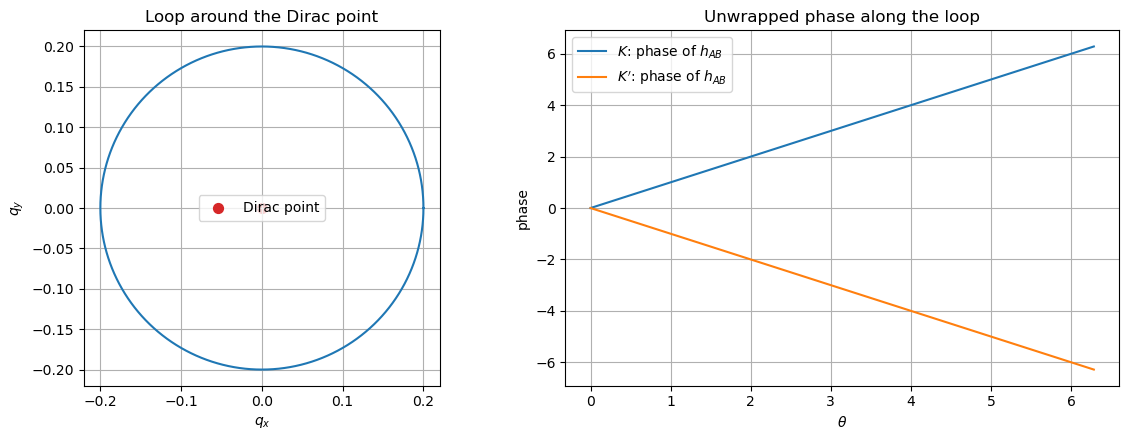

In [9]:
# 新建一个 1x2 的子图布局，左边画回路，右边画相位。
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 取左边子图，用来画围绕 Dirac 点的闭合回路。
ax = axes[0]
# 画出 q 空间里的闭合圆形回路。
ax.plot(qx, qy, color="tab:blue")
# 在中心标出 Dirac 点位置。
ax.scatter([0], [0], color="tab:red", s=50, label="Dirac point")
# 设置标题，说明这张图展示的是围绕 Dirac 点的回路。
ax.set_title("Loop around the Dirac point")
# 标记横坐标为 q_x。
ax.set_xlabel(r"$q_x$")
# 标记纵坐标为 q_y。
ax.set_ylabel(r"$q_y$")
# 设为等比例显示，避免把圆画成椭圆。
ax.set_aspect("equal")
# 显示图例。
ax.legend()

# 取右边子图，用来画沿回路的相位展开结果。
ax = axes[1]
# 画出 K 点模型的展开相位。
ax.plot(theta, phase_K, label=r"$K$: phase of $h_{AB}$")
# 画出 K' 点模型的展开相位。
ax.plot(theta, phase_Kp, label=r"$K'$: phase of $h_{AB}$")
# 设置标题，说明这里比较的是展开后的相位曲线。
ax.set_title("Unwrapped phase along the loop")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是相位。
ax.set_ylabel("phase")
# 显示图例。
ax.legend()

# 自动调整子图间距。
plt.tight_layout()


## 2. 再看分母费米线积分

源码里 `lambda_topo` 不是直接对量子度规积分，而是先积出下面这个量：

$$
\mathrm{fs\_inv\_gap\_integral}
=
\oint_{FS} ds\,\frac{|\nabla_k E|}{\Delta E^2}
$$

然后再用

$$
\lambda_{topo}
=
C_{topo}
\frac{(|W_K|+|W_{K'}|)^2}{\mathrm{fs\_inv\_gap\_integral}}
$$

来得到拓扑下界。

对这里的 massive Dirac toy model，下带能量是

$$
E_-(q) = -\sqrt{v^2 q^2 + m^2}
$$

费米面条件 $E_-(q_F)=\mu$ 给出圆形费米线半径：

$$
q_F = \frac{\sqrt{\mu^2-m^2}}{v}
$$

圆形费米线可以参数化成：

$$
q_x(\theta)=q_F\cos\theta,
\qquad
q_y(\theta)=q_F\sin\theta
$$

把费米线离散成相邻两点 $q_i$ 和 $q_{i+1}$ 后，连续积分就变成：

$$
\mathrm{fs\_inv\_gap\_integral}
\approx
\sum_i ds_i\,
\frac{|\nabla E(q_i^{\mathrm{mid}})|}{\Delta E^2(q_i^{\mathrm{mid}})}
$$

其中

$$
ds_i \approx |q_{i+1}-q_i|,
\qquad
q_i^{\mathrm{mid}} = \frac{q_i+q_{i+1}}{2}
$$

下面我们就按这个离散公式把分母积分算出来。


In [10]:
def lower_band_energy(qx, qy, v=v, mass=mass):
    # 计算下能带 E_-(q)。
    # qx*qx + qy*qy 就是 q^2，也就是离 Dirac 点的径向距离平方。
    # 根号内部 v^2 q^2 + m^2 对应 massive Dirac 色散关系。
    # 前面的负号表示这里取的是 lower band。
    return -np.sqrt(v * v * (qx * qx + qy * qy) + mass * mass)


def gap_ev(qx, qy, v=v, mass=mass):
    # 计算上下两条能带之间的能隙 Delta E(q)。
    # 对两带 Dirac 模型，上下带能量差正好是 2*sqrt(...)
    return 2.0 * np.sqrt(v * v * (qx * qx + qy * qy) + mass * mass)


def velocity_norm(qx, qy, v=v, mass=mass):
    # 先计算 q 的大小，也就是当前点到 Dirac 点的径向距离。
    q = np.sqrt(qx * qx + qy * qy)
    # 计算去掉正负号后的能量尺度 |E(q)|。
    energy_abs = np.sqrt(v * v * q * q + mass * mass)
    # 返回 |grad E| 的解析表达式 v^2 q / sqrt(v^2 q^2 + m^2)。
    return v * v * q / energy_abs


# 由费米面条件 E_-(q_F) = mu 反解出费米半径 q_F。
q_fermi = np.sqrt(mu * mu - mass * mass) / v
# 在 0 到 2pi 之间均匀取很多角度点，用来离散圆形费米线。
theta_fs = np.linspace(0.0, 2.0 * np.pi, num_segments, endpoint=False)
# 用圆参数方程生成费米线上的离散点。
segments = np.column_stack([q_fermi * np.cos(theta_fs), q_fermi * np.sin(theta_fs)])
# 把第一个点再拼到最后，构成闭合折线。
segments = np.vstack([segments, segments[0]])

# 取每一小段的中点，后面就在这些中点上采样中间量。
midpoints = 0.5 * (segments[:-1] + segments[1:])
# 计算相邻折线点之间的距离，这就是离散线积分里的每一小段长度 ds。
ds = np.linalg.norm(segments[1:] - segments[:-1], axis=1)
# 在每个中点上计算能隙 Delta E(k)。
sample_gap = np.array([gap_ev(x, y) for x, y in midpoints])
# 在每个中点上计算速度大小 |grad E(k)|。
sample_velocity = np.array([velocity_norm(x, y) for x, y in midpoints])

# 构造分母积分的被积函数：|grad E| / DeltaE^2。
# 用 np.maximum 对 DeltaE^2 做保护，保证数值稳定。
topo_denominator_kernel = sample_velocity / np.maximum(sample_gap**2, 1.0e-12)
# 把 ds * kernel 沿整条费米线求和，得到离散版分母积分。
fs_inv_gap_integral = float(np.sum(ds * topo_denominator_kernel))
# 用绕数分子除以分母积分，得到还没有乘 prefactor 的拓扑下界主体。
normalized_lambda_topo = (winding_sum_abs**2) / fs_inv_gap_integral

# 输出费米半径 q_F。
print(f"q_F = {q_fermi:.6f}")
# 输出分母费米线积分结果。
print(f"fs_inv_gap_integral = {fs_inv_gap_integral:.6f}")
# 输出归一化后的拓扑下界主体。
print(f"normalized lambda_topo = {normalized_lambda_topo:.6f}")
# 提醒这里还没有乘公共 prefactor C_topo。
print("real code still needs the prefactor C_topo")


q_F = 0.433705
fs_inv_gap_integral = 3.242613
normalized lambda_topo = 1.233573
real code still needs the prefactor C_topo


## 3. 图 1：费米线上的分母积分核长什么样

左图把下带能量画成背景，并把费米线画出来。

彩色点表示每一小段中点处的分母积分核：

$$
\frac{|\nabla E|}{\Delta E^2}
$$

右图把每一小段的真实贡献画出来：

$$
ds_i\times \frac{|\nabla E_i|}{\Delta E_i^2}
$$


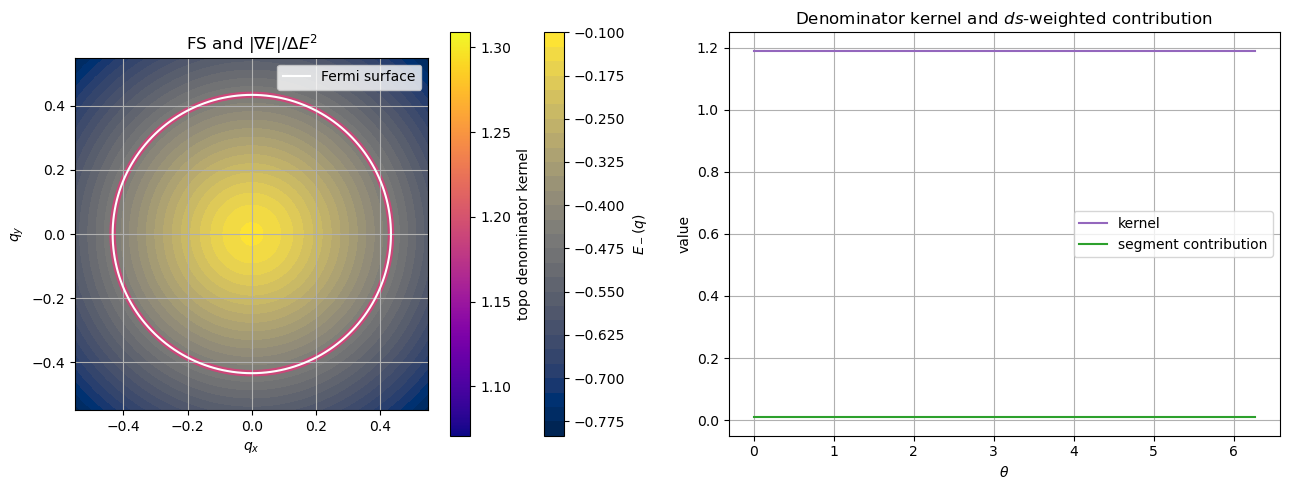

In [11]:
# 构造一个二维 q 空间网格，用来画下能带能量背景。
grid = np.linspace(-0.55, 0.55, 240)
# 把一维网格扩展成二维坐标网格。
qx_grid, qy_grid = np.meshgrid(grid, grid, indexing="xy")
# 在二维网格上计算下能带能量，作为背景标量场。
energy_grid = lower_band_energy(qx_grid, qy_grid)

# 新建一个 1x2 的子图布局。
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 取左边子图，用来画费米线在能量背景上的位置。
ax = axes[0]
# 用 contourf 画出下能带能量的填色背景。
im = ax.contourf(qx_grid, qy_grid, energy_grid, levels=30, cmap="cividis")
# 把离散费米线画成白色闭合曲线。
ax.plot(segments[:, 0], segments[:, 1], color="white", lw=1.5, label="Fermi surface")
# 把每段中点处的分母积分核用彩色散点画出来。
sc = ax.scatter(midpoints[:, 0], midpoints[:, 1], c=topo_denominator_kernel, s=14, cmap="plasma")
# 设置标题，说明左图画的是费米线和分母积分核。
ax.set_title(r"FS and $|\nabla E|/\Delta E^2$")
# 标记横坐标为 q_x。
ax.set_xlabel(r"$q_x$")
# 标记纵坐标为 q_y。
ax.set_ylabel(r"$q_y$")
# 保持 x、y 比例一致。
ax.set_aspect("equal")
# 显示图例。
ax.legend(loc="upper right")
# 给背景能量图加 colorbar。
fig.colorbar(im, ax=ax, label=r"$E_-(q)$")
# 给积分核散点加 colorbar。
fig.colorbar(sc, ax=ax, label="topo denominator kernel")

# 取右边子图，用来画沿费米线参数 theta 的一维分布。
ax = axes[1]
# 画出分母积分核随角度的变化。
ax.plot(theta_fs, topo_denominator_kernel, label="kernel", color="tab:purple")
# 画出每一段真实贡献 ds * kernel 随角度的变化。
ax.plot(theta_fs, ds * topo_denominator_kernel, label="segment contribution", color="tab:green")
# 设置标题，说明右图比较的是积分核和 ds 加权后的贡献。
ax.set_title("Denominator kernel and $ds$-weighted contribution")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是数值大小。
ax.set_ylabel("value")
# 显示图例。
ax.legend()

# 自动调整子图间距。
plt.tight_layout()


## 4. 图 2：把中间量单独拆开来看

上面的图已经把最终分母积分核

$$
\frac{|\nabla E|}{\Delta E^2}
$$

画出来了，但如果只看最终组合量，还是不容易知道到底是分子还是分母在起主要作用。

所以这里把 2 个中间量和最终核单独画出来：

$$
\Delta E(\theta),
\qquad
|\nabla E(\theta)|,
\qquad
\frac{|\nabla E(\theta)|}{\Delta E^2(\theta)}
$$

这样就能直接看到：代码不是“神秘地算出了一个 kernel”，而是先分别算出能隙和速度，再把它们按公式组合起来。


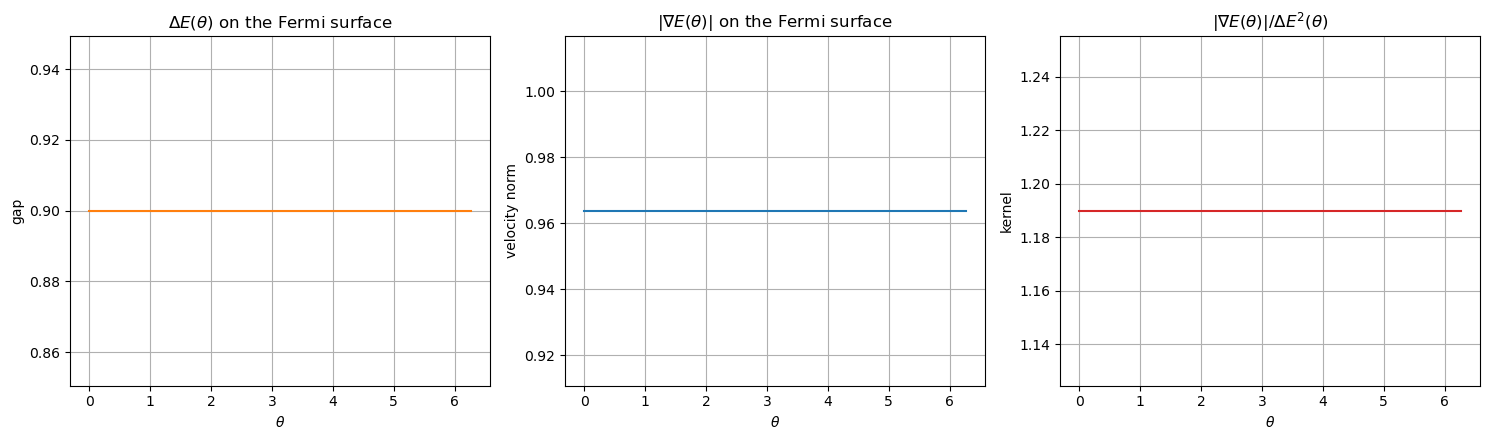

In [12]:
# 新建一个 1x3 的子图布局，分别画能隙、速度和分母积分核。
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 取第一个子图，用来画能隙随角度的变化。
ax = axes[0]
# 画出 sample_gap，也就是每个中点上的 Delta E。
ax.plot(theta_fs, sample_gap, color="tab:orange")
# 设置标题，明确这幅图画的是能隙。
ax.set_title(r"$\Delta E(\theta)$ on the Fermi surface")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是能隙大小。
ax.set_ylabel("gap")

# 取第二个子图，用来画速度大小随角度的变化。
ax = axes[1]
# 画出 sample_velocity，也就是每个中点上的 |grad E|。
ax.plot(theta_fs, sample_velocity, color="tab:blue")
# 设置标题，明确这是速度大小。
ax.set_title(r"$|\nabla E(\theta)|$ on the Fermi surface")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是速度大小。
ax.set_ylabel("velocity norm")

# 取第三个子图，用来画最终分母积分核随角度的变化。
ax = axes[2]
# 画出 topo_denominator_kernel，也就是每个中点上的 |grad E| / DeltaE^2。
ax.plot(theta_fs, topo_denominator_kernel, color="tab:red")
# 设置标题，明确这是最终分母积分核。
ax.set_title(r"$|\nabla E(\theta)| / \Delta E^2(\theta)$")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是最终核的大小。
ax.set_ylabel("kernel")

# 自动调整子图间距。
plt.tight_layout()


## 5. 图 3：改变化学势时，拓扑下界怎么变

下面把 $\mu$ 扫一遍。这里我们只画

$$
\widetilde{\lambda}_{topo}
=\frac{(|W_K|+|W_{K'}|)^2}{\oint_{FS} ds\,|\nabla E|/\Delta E^2}
$$

也就是把真正的公共 prefactor $C_{topo}$ 先拿掉，这样更容易看清楚费米线积分本身的作用。


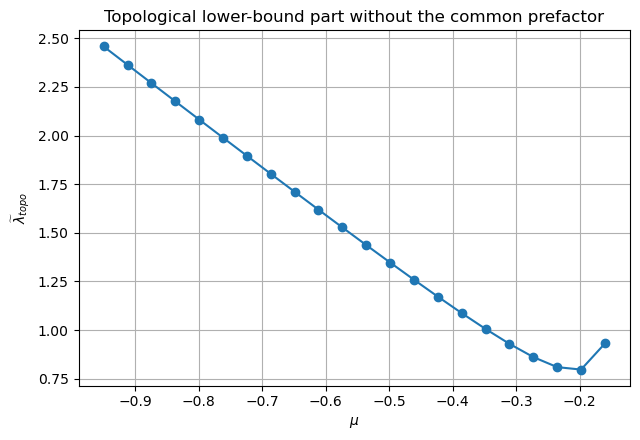

In [13]:
# 在一段化学势区间上做扫描，观察归一化拓扑下界主体如何变化。
mu_list = np.linspace(-0.95, -0.16, 22)
# 准备一个列表，用来保存每个化学势下的归一化拓扑下界主体。
normalized_topo_list = []

# 依次遍历不同的化学势。
for mu_i in mu_list:
    # 对当前化学势重新求出费米半径 q_F。
    qf = np.sqrt(mu_i * mu_i - mass * mass) / v
    # 对当前费米线重新生成角度离散点。
    th = np.linspace(0.0, 2.0 * np.pi, num_segments, endpoint=False)
    # 用圆参数方程生成当前化学势下的费米线折线点。
    seg = np.column_stack([qf * np.cos(th), qf * np.sin(th)])
    # 把第一个点再接到最后，形成闭合路径。
    seg = np.vstack([seg, seg[0]])
    # 计算每一小段的中点。
    mids = 0.5 * (seg[:-1] + seg[1:])
    # 计算每一小段的长度 ds。
    ds_local = np.linalg.norm(seg[1:] - seg[:-1], axis=1)
    # 在中点上计算当前化学势对应的局部能隙。
    gap_local = np.array([gap_ev(x, y) for x, y in mids])
    # 在中点上计算当前化学势对应的局部速度大小。
    vel_local = np.array([velocity_norm(x, y) for x, y in mids])
    # 按离散线积分公式计算当前化学势下的分母积分。
    denom_local = np.sum(ds_local * vel_local / np.maximum(gap_local**2, 1.0e-12))
    # 用固定的绕数分子除以当前分母，得到归一化拓扑下界主体。
    normalized_topo_list.append((winding_sum_abs**2) / denom_local)

# 新建一张图，用来画归一化拓扑下界主体随化学势的变化。
plt.figure(figsize=(6.5, 4.5))
# 画出扫描曲线。
plt.plot(mu_list, normalized_topo_list, marker="o")
# 标记横坐标是化学势 mu。
plt.xlabel(r"$\mu$")
# 标记纵坐标是归一化拓扑下界主体。
plt.ylabel(r"$\widetilde{\lambda}_{topo}$")
# 设置标题，说明这里还没有乘公共 prefactor。
plt.title("Topological lower-bound part without the common prefactor")
# 自动调整图形边距。
plt.tight_layout()


## 6. 和 `core.py` 的一一对应

这个 demo 和源码的关键对应关系可以整理成一张表：

| 公式对象 | toy model 变量 | `core.py` 对象 | 物理意义 | 数值角色 |
|---|---|---|---|---|
| $h_{AB}(q)$ 的相位 | `phase_K`, `phase_Kp` | 非对角元相位 | 绕数来源 | 拓扑输入 |
| $W_K$, $W_{K'}$ | `winding_K`, `winding_Kp` | winding number | Dirac 点绕数 | 分子输入 |
| $|W_K|+|W_{K'}|$ | `winding_sum_abs` | `winding_sum_abs` | 绕数绝对值之和 | 拓扑分子 |
| $FS$ | `segments` | `segments_reduced` | 费米线 | 离散积分路径 |
| $q_i^{\mathrm{mid}}$ | `midpoints` | `mid_reduced` | 每段中点 | 采样位置 |
| $ds_i$ | `ds` | `ds` | 线元长度 | 权重 |
| $\Delta E$ | `sample_gap` | `sampled["gap_ev"]` | 上下带能隙 | 分母中的能隙项 |
| $|\nabla E|$ | `sample_velocity` | `sampled["velocity_norm"]` | 能带速度大小 | 分母中的速度项 |
| $|\nabla E| / \Delta E^2$ | `topo_denominator_kernel` | `velocity_norm / gap_ev**2` | 分母积分核 | 被积函数 |
| $\oint ds\,|\nabla E|/\Delta E^2$ | `fs_inv_gap_integral` | `fs_inv_gap_integral` | 拓扑下界分母 | 费米线积分结果 |
| $(|W_K|+|W_{K'}|)^2 / \mathrm{fs\_inv\_gap\_integral}$ | `normalized_lambda_topo` | `lambda_topo / C_topo` | 归一化拓扑下界主体 | 最终离散结果 |

所以 `lambda_topo` 的结构可以分成两半理解：

1. 拓扑输入：来自 Dirac 点绕数 $W$
2. 费米线输入：来自 $\oint ds\,|\nabla E|/\Delta E^2$

最后两者在 `lambda_decomposition_scan()` 里乘上 prefactor 合并，才得到真正输出到 `lambda_scan.json` 的 `lambda_topo`。

## 7. 常见错误和检查点

如果这类代码结果不对，优先检查下面几项：

1. 计算绕数时是否真的对相位做了 `unwrap`；不展开相位，跳变会把绕数算错。
2. K 点和 K' 点的非对角元模型是否写反；两者的相位绕行方向应该相反。
3. `mu` 和 `mass` 是否满足 $|\mu| > m$；否则根本没有这条圆形费米线。
4. `segments` 是否真正闭合；如果没把第一个点接回最后一个点，就会漏掉最后一段。
5. `np.maximum(sample_gap**2, 1.0e-12)` 这种保护项是否保留；分母太小时需要数值稳定性保护。
6. 分母积分里是否真的使用了中点采样；改成端点采样会增加离散误差。
7. 绘图字符串里的 LaTeX 是否统一用了 raw string；像 `r"$\theta$"`、`r"$|\nabla E|$"` 这种写法更稳定。
